# Dataset Exploration

Loads the 25 hand-verified problems in `data/problems.json` and summarizes them:
count, category balance, and a preview table with the verification notes.

The `notes` column shows the derivation of each answer so the team can re-verify.

In [4]:
import json
import os
import pandas as pd

PROBLEMS_PATH = os.path.join('..', 'data', 'problems.json')
with open(PROBLEMS_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

problems = data['problems']
df = pd.DataFrame(problems)
print(f"Total problems: {len(df)}")
df.head()

Total problems: 10


,id,category,question,answer,notes
0,P01,math_logic,In how many ways can you tile a 3x8 rectangle ...,153,Recurrence a(n)=4a(n-1)-a(n-2) for a 3x2n boar...
1,P02,math_logic,How many trailing zeros does 100! (100 factori...,24,floor(100/5) + floor(100/25) = 20 + 4 = 24.
2,P03,math_logic,How many positive divisors does 360 have?,24,360 = 2^3 * 3^2 * 5 -> (3+1)(2+1)(1+1) = 24.
3,P04,math_logic,How many distinct arrangements are there of th...,60,6! / (3! 2! 1!) = 720 / 12 = 60.
4,P05,math_logic,A fair six-sided die is rolled twice. What is ...,1/6,6 favorable ordered outcomes out of 36 -> 6/36...


category
math_logic    8
physics       2
Name: count, dtype: int64


<Axes: title={'center': 'Problems per category'}, xlabel='category'>

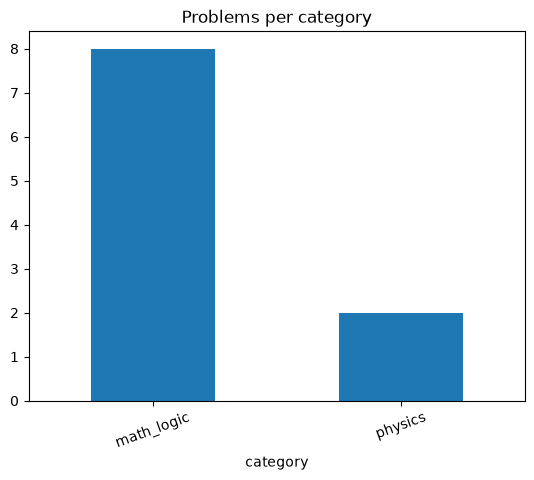

In [5]:
# Category balance
counts = df['category'].value_counts()
print(counts)
counts.plot(kind='bar', title='Problems per category', rot=20)

In [6]:
# Full table for re-verification: question, expected answer, and derivation notes
pd.set_option('display.max_colwidth', None)
df[['id', 'category', 'question', 'answer', 'notes']]

,id,category,question,answer,notes
0,P01,math_logic,In how many ways can you tile a 3x8 rectangle with 2x1 dominoes?,153,"Recurrence a(n)=4a(n-1)-a(n-2) for a 3x2n board; a(0)=1, a(1)=3 -> a(2)=11, a(3)=41, a(4)=153."
1,P02,math_logic,How many trailing zeros does 100! (100 factorial) have?,24,floor(100/5) + floor(100/25) = 20 + 4 = 24.
2,P03,math_logic,How many positive divisors does 360 have?,24,360 = 2^3 * 3^2 * 5 -> (3+1)(2+1)(1+1) = 24.
3,P04,math_logic,How many distinct arrangements are there of the letters in the word BANANA?,60,6! / (3! 2! 1!) = 720 / 12 = 60.
4,P05,math_logic,A fair six-sided die is rolled twice. What is the probability that the sum of the two rolls equals 7? Give the answer as a simplified fraction.,1/6,6 favorable ordered outcomes out of 36 -> 6/36 = 1/6.
5,P06,math_logic,"In the Monty Hall problem with 3 doors, you pick a door, the host (who knows what is behind the doors) opens a different door revealing a goat, and offers you the chance to switch. What is the probability of winning the car if you switch? Give a simplified fraction.",2/3,"Switching wins whenever the initial pick was wrong, which is 2/3 of the time."
6,P07,math_logic,"What is the minimum number of people needed in a room so that the probability of at least two sharing a birthday exceeds 50% (assume 365 equally likely birthdays, ignore leap years)?",23,Birthday paradox: at 23 people P(shared) ~ 0.507 > 0.5; at 22 it is ~0.476.
7,P08,math_logic,What is the sum of all integers from 1 to 100 inclusive?,5050,n(n+1)/2 = 100*101/2 = 5050.
8,P09,physics,"An object is dropped from rest. Using g = 9.8 m/s^2 and ignoring air resistance, how far (in meters) does it fall during the first 3 seconds? Give the numeric value in meters.",44.1,d = 0.5 * g * t^2 = 0.5 * 9.8 * 3^2 = 44.1 m.
9,P10,physics,"A projectile is launched at 45 degrees with an initial speed of 20 m/s on level ground. Using g = 9.8 m/s^2 and ignoring air resistance, what is its horizontal range in meters (round to one decimal place)?",40.8,R = v^2 * sin(2*theta) / g = 400 * sin(90) / 9.8 = 400/9.8 = 40.816 m.
